In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

#https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('weatherAUS.csv')
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
# Data Cleaning

In [3]:
filter = (df.RainTomorrow.isna())
df = df[~filter]
len(df)

142193

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64
 18  

In [6]:
df['Year']=pd.to_datetime(df['Date']).dt.strftime('%Y')
df['Month']=pd.to_datetime(df['Date']).dt.strftime('%m')
df['Day']=pd.to_datetime(df['Date']).dt.strftime('%d')
df.drop('Date', axis = 1, inplace = True)
df.head(5)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,01
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,02
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,03
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,04
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,05


In [9]:
numerical=df.select_dtypes(include=[np.number])
categorical=df.select_dtypes(exclude=[np.number])

In [10]:
label_encoder = LabelEncoder()
for column in categorical:
    df[column] = label_encoder.fit_transform(df[column])
df.head(10)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,2,13.4,22.9,0.6,NaN,NaN,13,44.0,13,14,...,1007.1,8.0,NaN,16.9,21.8,0,0,1,11,0
1,2,7.4,25.1,0.0,NaN,NaN,14,44.0,6,15,...,1007.8,NaN,NaN,17.2,24.3,0,0,1,11,1
2,2,12.9,25.7,0.0,NaN,NaN,15,46.0,13,15,...,1008.7,NaN,2.0,21.0,23.2,0,0,1,11,2
3,2,9.2,28.0,0.0,NaN,NaN,4,24.0,9,0,...,1012.8,NaN,NaN,18.1,26.5,0,0,1,11,3
4,2,17.5,32.3,1.0,NaN,NaN,13,41.0,1,7,...,1006.0,7.0,8.0,17.8,29.7,0,0,1,11,4
5,2,14.6,29.7,0.2,NaN,NaN,14,56.0,13,13,...,1005.4,NaN,NaN,20.6,28.9,0,0,1,11,5
6,2,14.3,25.0,0.0,NaN,NaN,13,50.0,12,13,...,1008.2,1.0,NaN,18.1,24.6,0,0,1,11,6
7,2,7.7,26.7,0.0,NaN,NaN,13,35.0,10,13,...,1010.1,NaN,NaN,16.3,25.5,0,0,1,11,7
8,2,9.7,31.9,0.0,NaN,NaN,6,80.0,9,7,...,1003.6,NaN,NaN,18.3,30.2,0,1,1,11,8
9,2,13.1,30.1,1.4,NaN,NaN,13,28.0,8,10,...,1005.7,NaN,NaN,20.1,28.2,1,0,1,11,9


In [11]:
null = pd.DataFrame({'Null Values' : numerical.isna().sum(), 'Percentage Null Values' : (numerical.isna().sum()) / (numerical.shape[0]) * (100)})
null

,Null Values,Percentage Null Values
Location,0,0.000000
MinTemp,637,0.447983
MaxTemp,322,0.226453
Rainfall,1406,0.988797
Evaporation,60843,42.789026
Sunshine,67816,47.692924
WindGustDir,0,0.000000
WindGustSpeed,9270,6.519308
WindDir9am,0,0.000000
WindDir3pm,0,0.000000


In [ ]:
#Filling missing values in numerical columns with mean values

In [12]:
nan_replacements = {"MinTemp":numerical['MinTemp'].mean() ,"MaxTemp": numerical['MaxTemp'].mean(), "Rainfall": numerical['Rainfall'].mean(), "Evaporation": numerical['Evaporation'].mean(), "Sunshine": numerical['Sunshine'].mean(), "WindGustSpeed": numerical['WindGustSpeed'].mean(), "WindSpeed9am": numerical['WindSpeed9am'].mean(), "WindSpeed3pm": numerical['WindSpeed3pm'].mean(), "Humidity9am": numerical['Humidity9am'].mean(), "Humidity3pm": numerical['Humidity3pm'].mean(), "Pressure9am": numerical['Pressure9am'].mean(), "Pressure3pm": numerical['Pressure3pm'].mean(), "Cloud9am": numerical['Cloud9am'].mean(), "Cloud3pm": numerical['Cloud3pm'].mean(), "Temp9am": numerical['Temp9am'].mean(), "Temp3pm": numerical['Temp3pm'].mean()}
numerical = numerical.fillna(nan_replacements)
null = pd.DataFrame({'Null Values' : numerical.isna().sum(), 'Percentage Null Values' : (numerical.isna().sum()) / (numerical.shape[0]) * (100)})
null


,Null Values,Percentage Null Values
Location,0,0.0
MinTemp,0,0.0
MaxTemp,0,0.0
Rainfall,0,0.0
Evaporation,0,0.0
Sunshine,0,0.0
WindGustDir,0,0.0
WindGustSpeed,0,0.0
WindDir9am,0,0.0
WindDir3pm,0,0.0


In [13]:
null = pd.DataFrame({'Null Values' : categorical.isna().sum(), 'Percentage Null Values' : (categorical.isna().sum()) / (categorical.shape[0]) * (100)})
null

,Null Values,Percentage Null Values


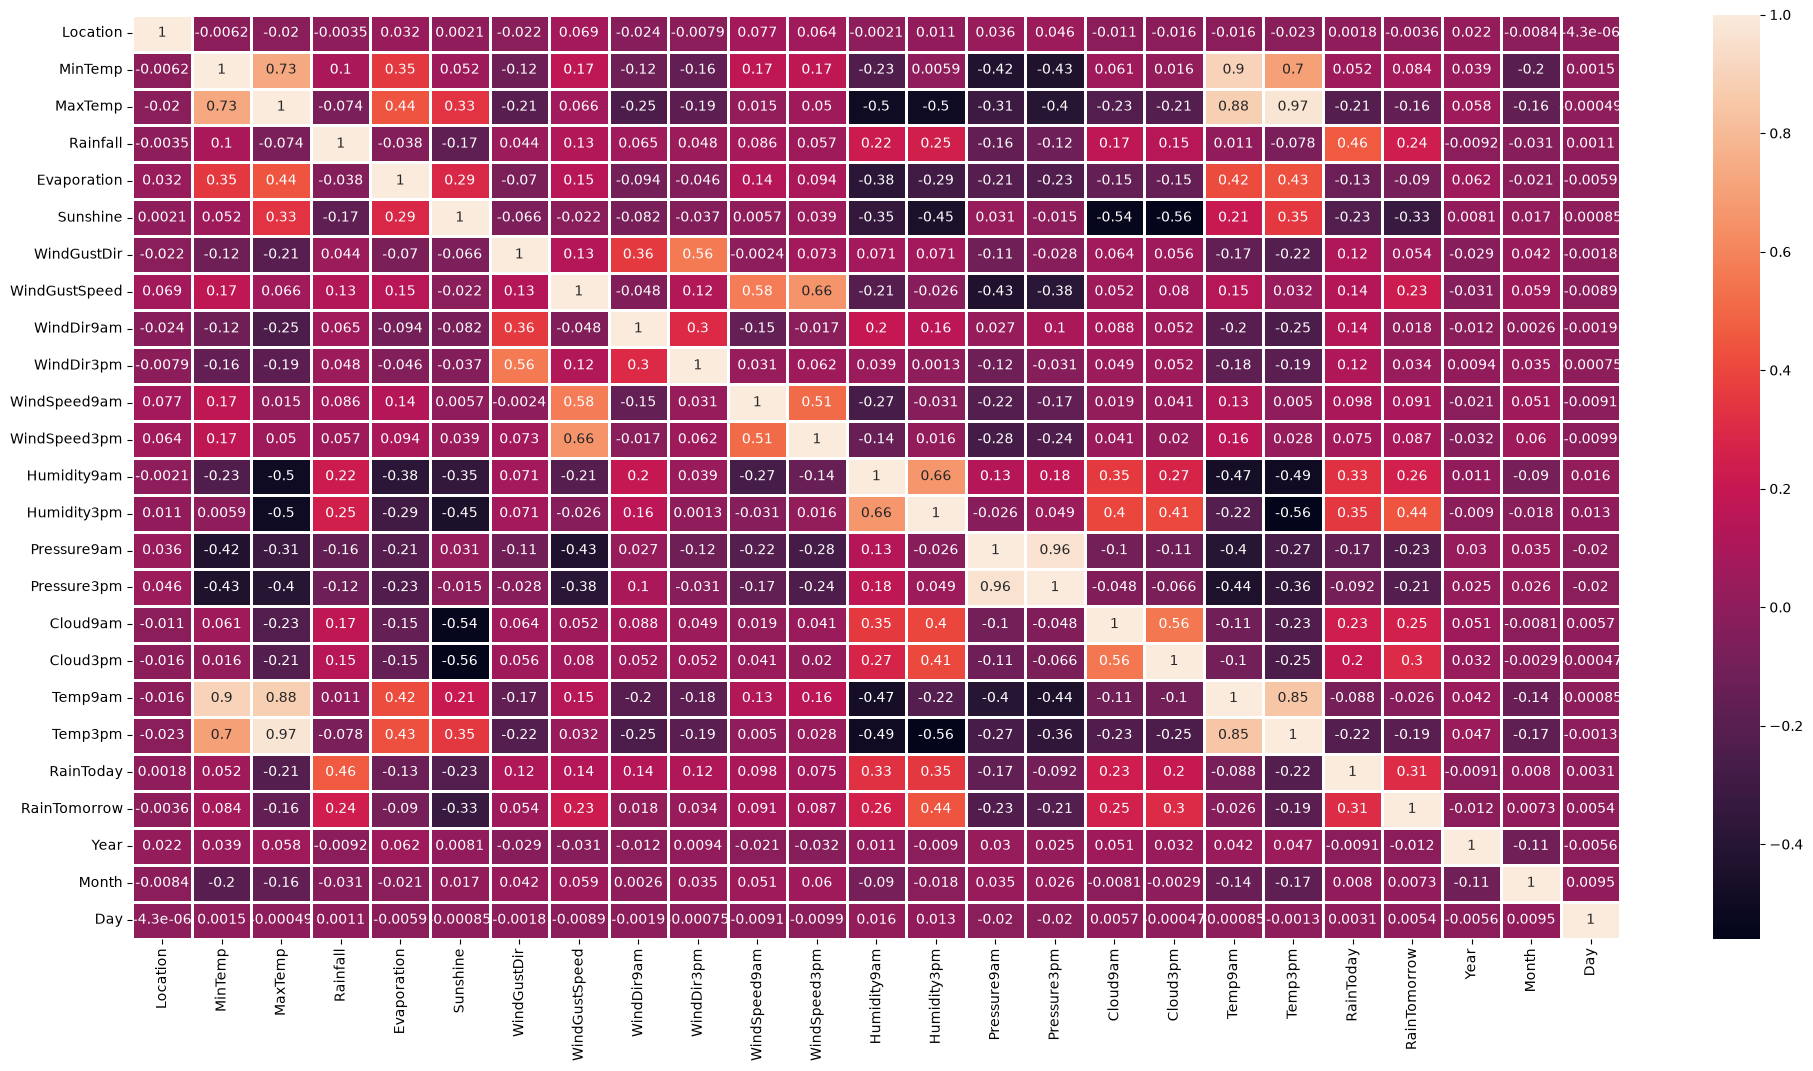

In [14]:
plt.figure(figsize=(24, 12))

corr = numerical.corr()
sns.heatmap(corr, annot=True, linewidths=1)
plt.show()

In [15]:
useless_col = ['MinTemp', 'MaxTemp', 'Pressure3pm', 'Temp9am']

numerical.drop(useless_col, axis = 1, inplace = True)

In [ ]:
#Preparing the data for training and testing

In [16]:
X = numerical.drop(['RainTomorrow'], axis=1)
y = numerical['RainTomorrow']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=5 )
gbc.fit(X_train, y_train)
 
pred_y = gbc.predict(X_test)
 
acc = accuracy_score(y_test, pred_y)
print("Gradient Boosting Classifier accuracy is : {:.2f}".format(acc))

Gradient Boosting Classifier accuracy is : 0.85


In [28]:
conf_df = pd.DataFrame(
    confusion_matrix(y_test, pred_y),
    index=[
        "Fact: No Rain",
        "Fact: Rain",
    ], 
    columns=[
        "Prediction: No Rain",
        "Prediction: Rain",
    ], 
)

print(conf_df)

               Prediction: No Rain  Prediction: Rain
Fact: No Rain                20919              1179
Fact: Rain                    3175              3166


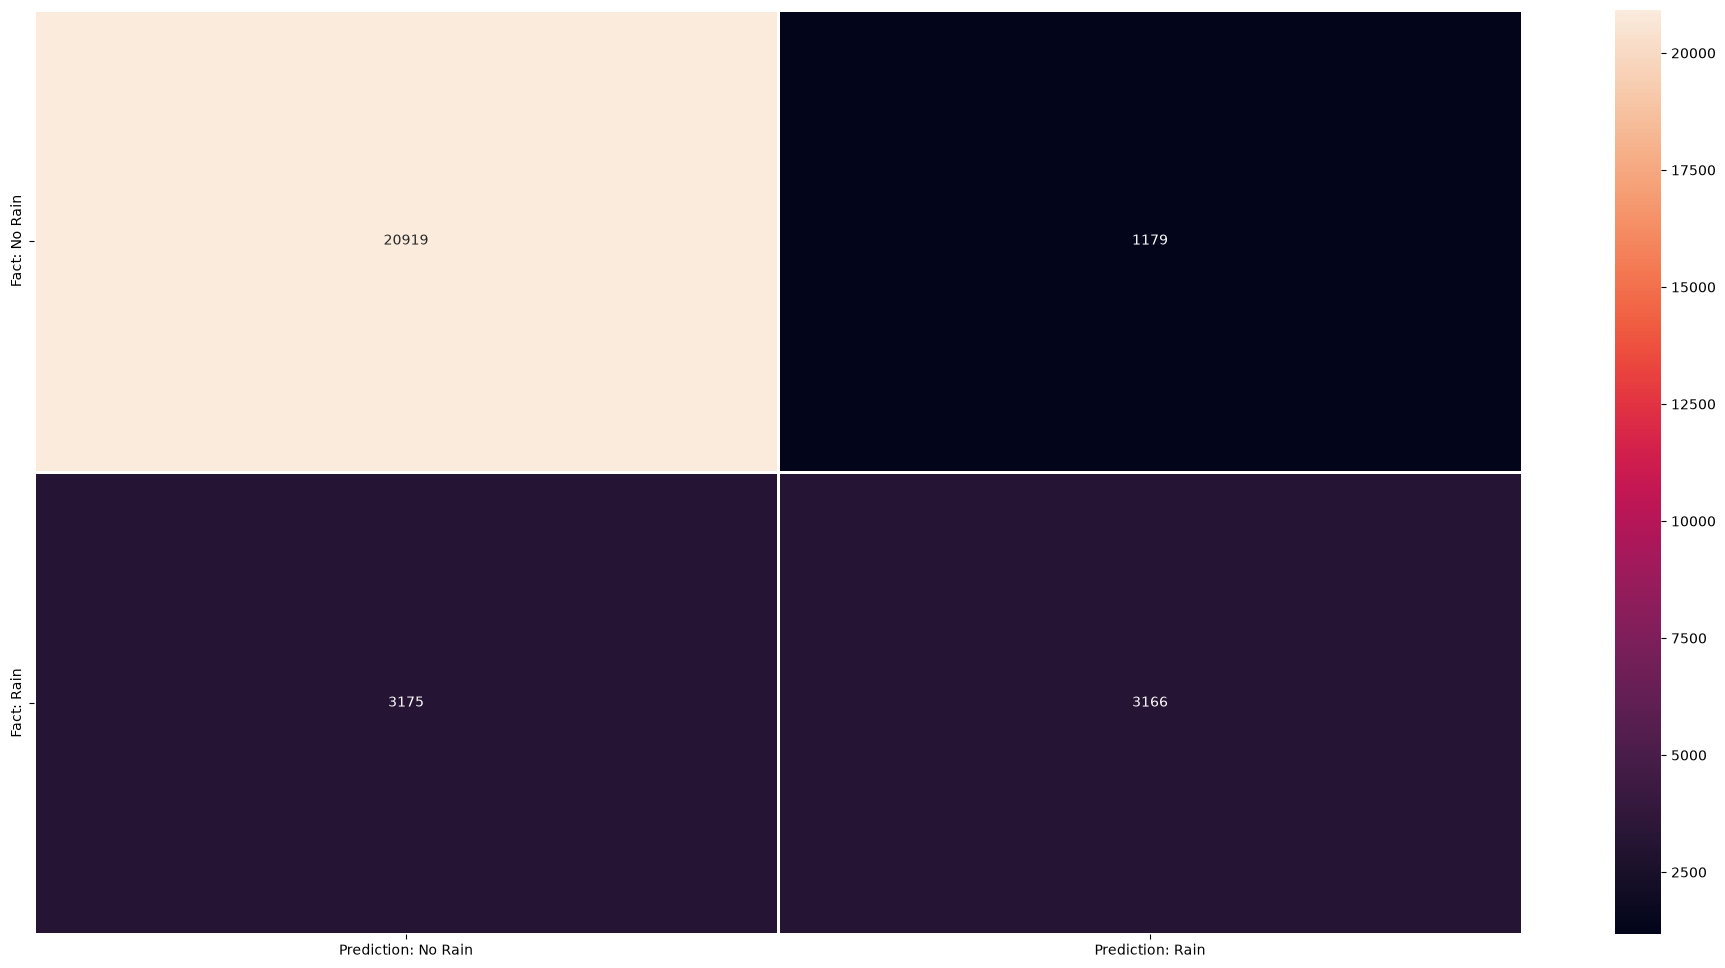

In [30]:
plt.figure(figsize=(24, 12))

sns.heatmap(conf_df, annot=True, fmt="d", linewidths=1)
plt.show()